M3: mu ~ N(0, I), y|mu ~ N(mu, 3I)
with MMD summary space regularization
D=20, N=100, S=2D

In [16]:
import numpy as np
import bayesflow as bf
import keras
from pathlib import Path

In [17]:
from tqdm.auto import tqdm as original_tqdm
import bayesflow.approximators.helpers.samplers as bf_samplers
import bayesflow.approximators.helpers.conditions as bf_conditions

def quiet_tqdm(*args, **kwargs):
    kwargs["disable"] = True
    return original_tqdm(*args, **kwargs)

bf_samplers.tqdm = quiet_tqdm
bf_conditions.tqdm = quiet_tqdm


In [18]:
RNG=np.random.default_rng(2025)
num_dims=20
num_obs=100
mu_prior_mean=0
mu_prior_std=1
likelihood_std=3

In [19]:
# simulator
def prior(mu=mu_prior_mean, sigma=mu_prior_std):
    mu = RNG.normal(loc=mu, scale=sigma, size=num_dims)
    return dict(mu=mu)
def likelihood(mu):
    x =RNG.normal(loc=mu, scale=likelihood_std, size=(num_obs, num_dims))
    return dict(x=x)
simulator=bf.make_simulator([prior,likelihood])

In [20]:
# adapter 
adapter = (bf.adapters.Adapter()
                        .convert_dtype("float64", "float32")
                        .rename('mu', 'inference_variables')
                        .rename('x', 'summary_variables')
                )

In [21]:
# networks
summary_net = bf.networks.DeepSet(
    summary_dim=2*num_dims, base_distribution="normal"
)

inference_net = bf.networks.CouplingFlow()

In [22]:
workflow = bf.BasicWorkflow(simulator=simulator,
                                          adapter=adapter,
                                          summary_network=summary_net,
                                          inference_network=inference_net,
                                          standardize="all"
                                          )
epochs=100
batch_size=64
num_batches_per_epoch=128
learning_rate=keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=1e-4, 
            decay_steps=epochs * num_batches_per_epoch
            )
workflow.approximator.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate))

In [23]:
history = workflow.fit_online(epochs=epochs,batch_size=batch_size,num_batches_per_epoch=num_batches_per_epoch)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 16s 80ms/step - loss: 25.3164 - loss/inference_loss: 24.6569 - loss/summary_loss: 0.6595
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step - loss: 20.2562 - loss/inference_loss: 19.6117 - loss/summary_loss: 0.6445
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - loss: 17.5936 - loss/inference_loss: 17.0067 - loss/summary_loss: 0.5869
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 12s 97ms/step - loss: 16.3134 - loss/inference_loss: 15.8456 - loss/summary_loss: 0.4679
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - loss: 14.1155 - loss/inference_loss: 13.6781 - loss/summary_loss: 0.4373
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 12s 97ms/step - loss: 13.2713 - loss/inference_loss: 12.8853 - loss/summary_loss: 0.3860
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 13s 98ms/step - loss: 12.4832 - loss/inference_loss: 12.1246 - loss/summary_loss: 0.3586
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 13s 103ms/step - loss: 11.4998 - loss/inference_l

INFO:bayesflow:Training completed in 23.90 minutes.


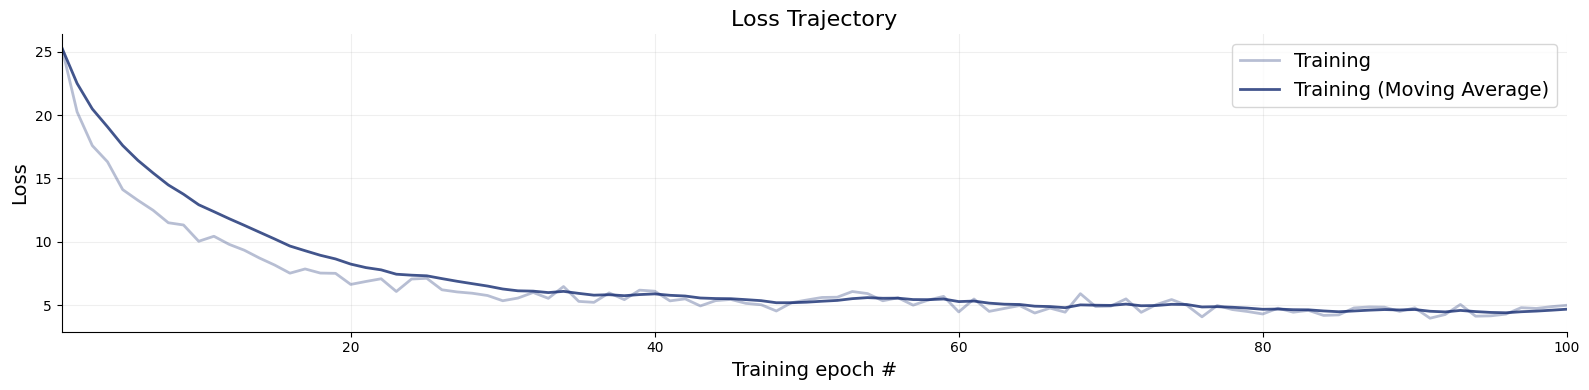

In [24]:
f=bf.diagnostics.plots.loss(history)

In [25]:
# Generate test datasets and get posterior samples and perform diagnostics
num_samples = 1000 #number of posterior samples
val_sims = simulator.sample(200) # validation data
post_draws = workflow.sample(conditions=val_sims, num_samples=num_samples)
post_draws.keys()


INFO:bayesflow:Sampling completed in 1.92 seconds.


dict_keys(['mu'])

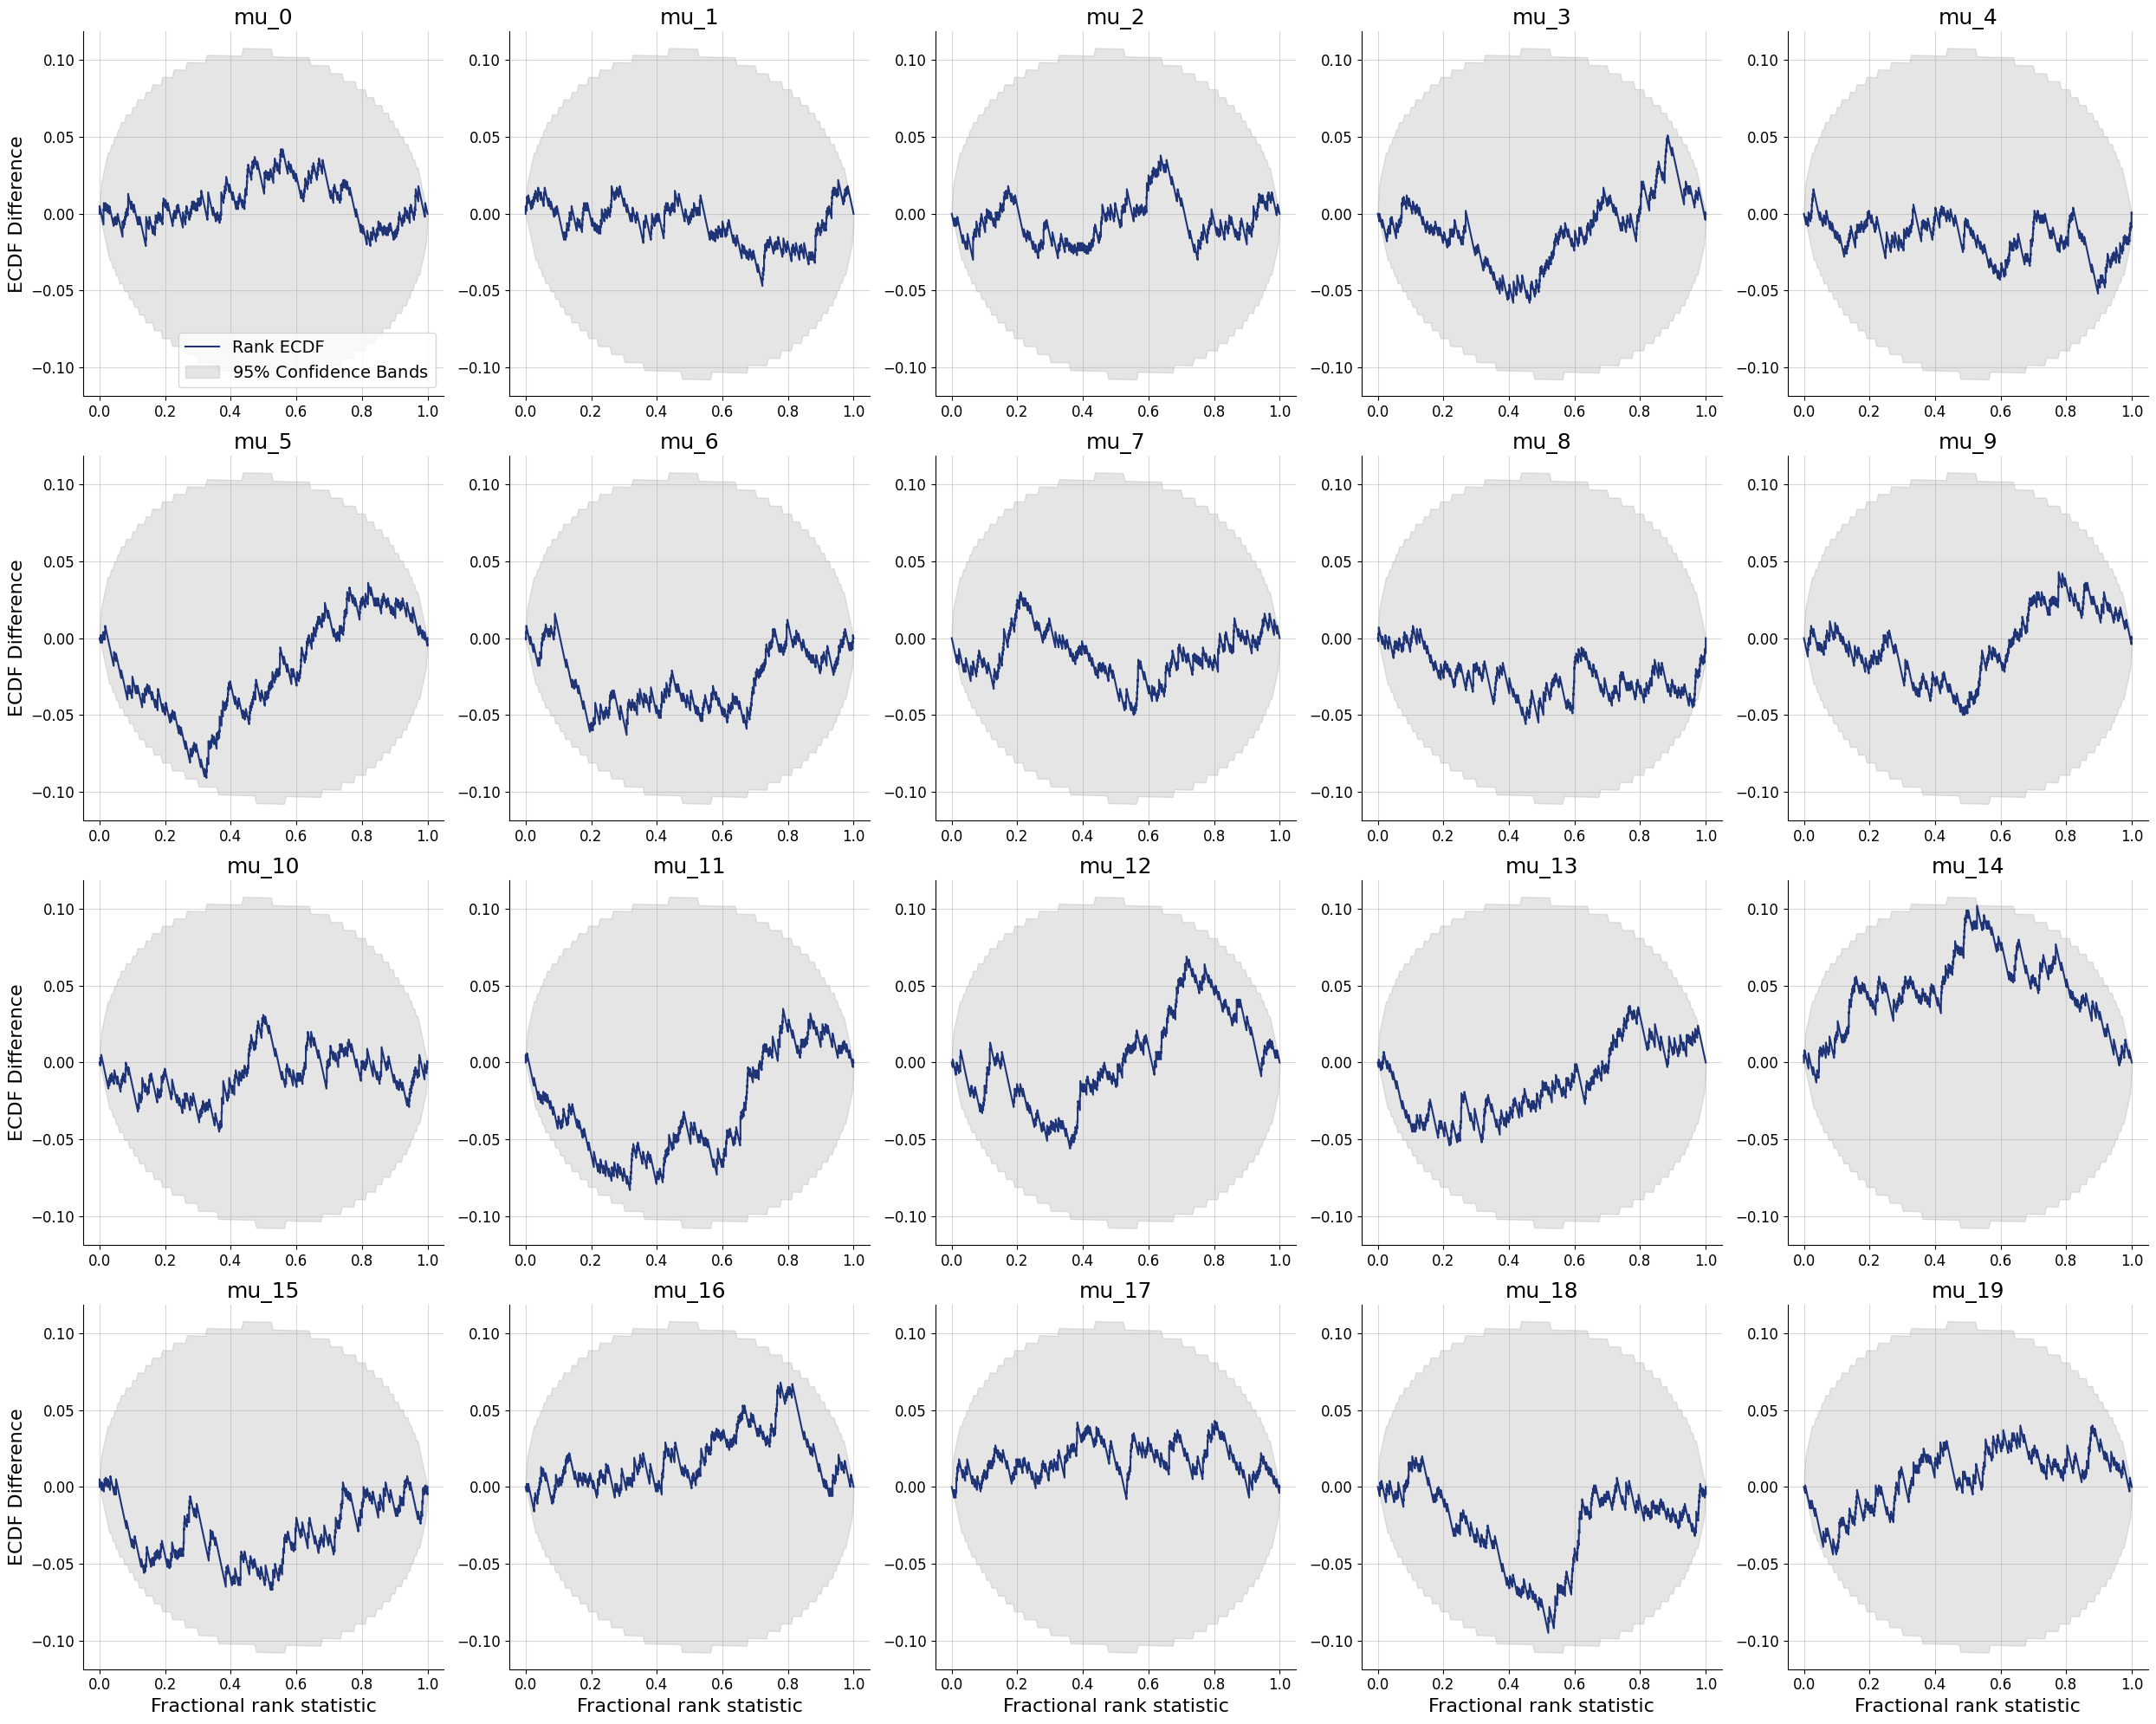

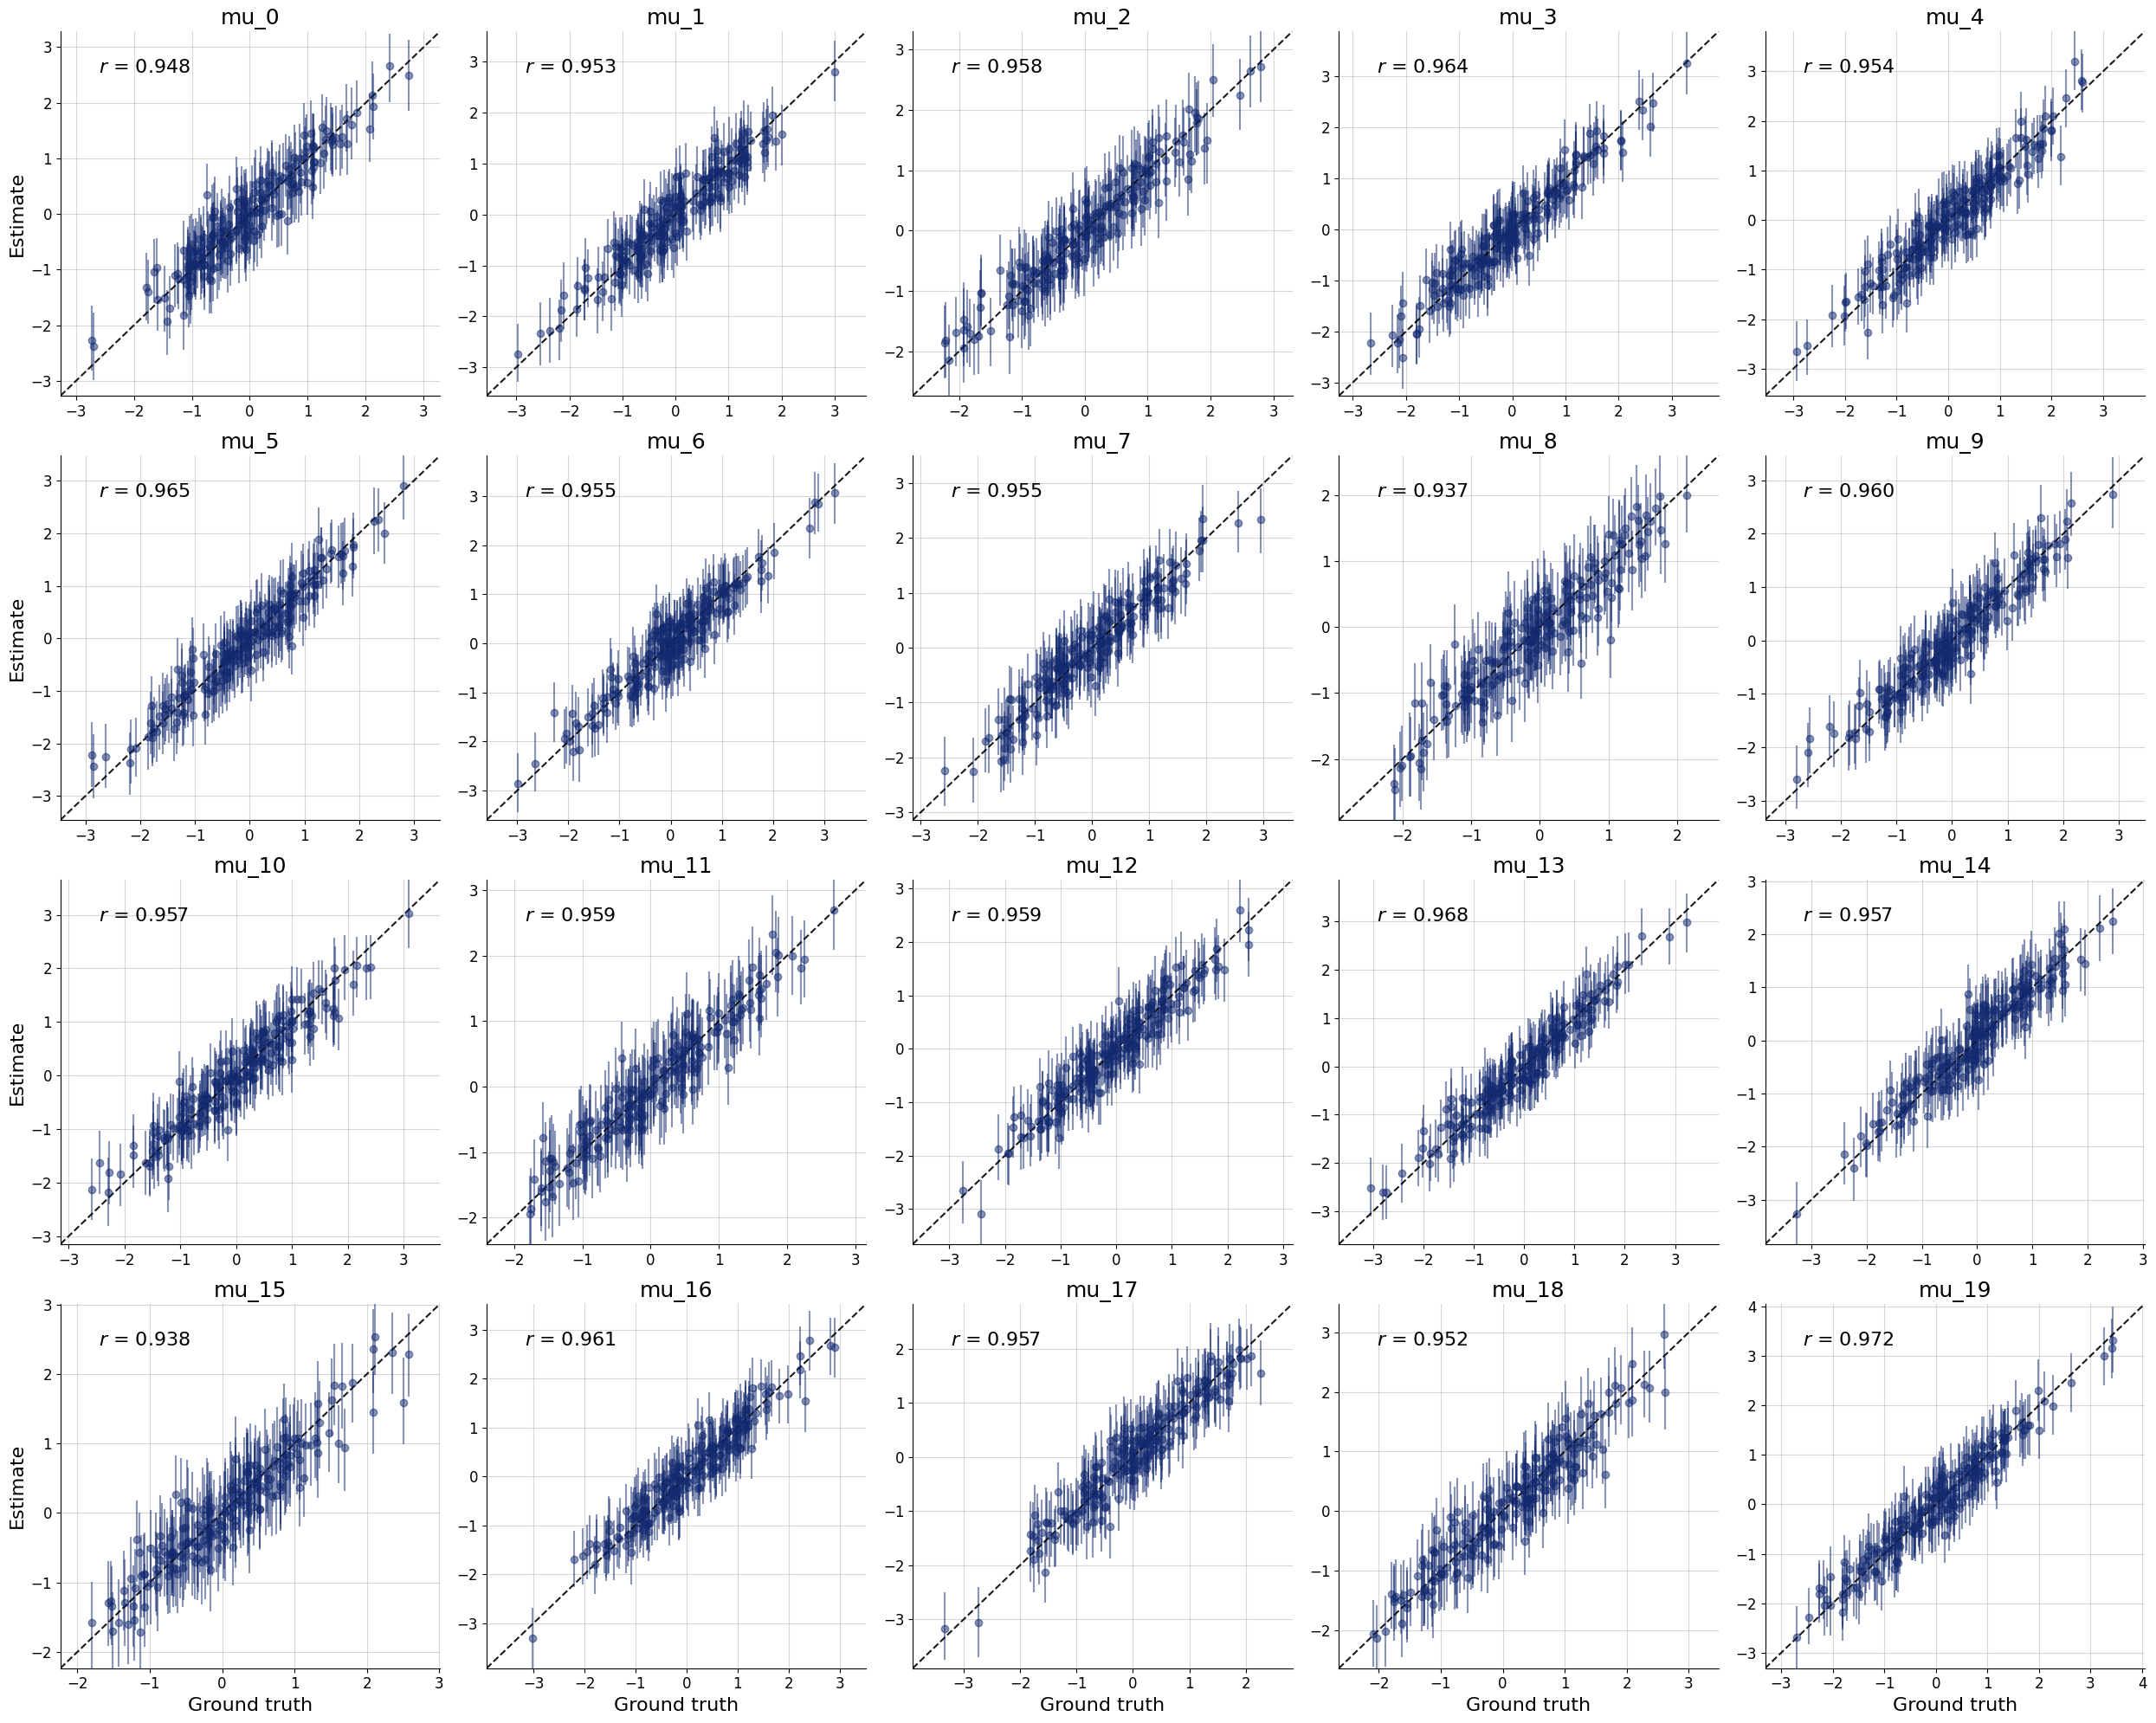

In [26]:
# f1 = bf.diagnostics.plots.calibration_histogram(post_draws, val_sims)
f2 = bf.diagnostics.plots.calibration_ecdf(post_draws, val_sims,difference=True)
f3 = bf.diagnostics.plots.recovery(post_draws, val_sims)

In [27]:
# Save the trained approximator
filepath = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/networks") / "m3_s_20d_100n.keras"
filepath.parent.mkdir(exist_ok=True)
workflow.approximator.save(filepath=filepath)

In [28]:
# load approximator
filepath = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/networks") / "m3_s_20d_100n.keras"
approximator = keras.saving.load_model(filepath)

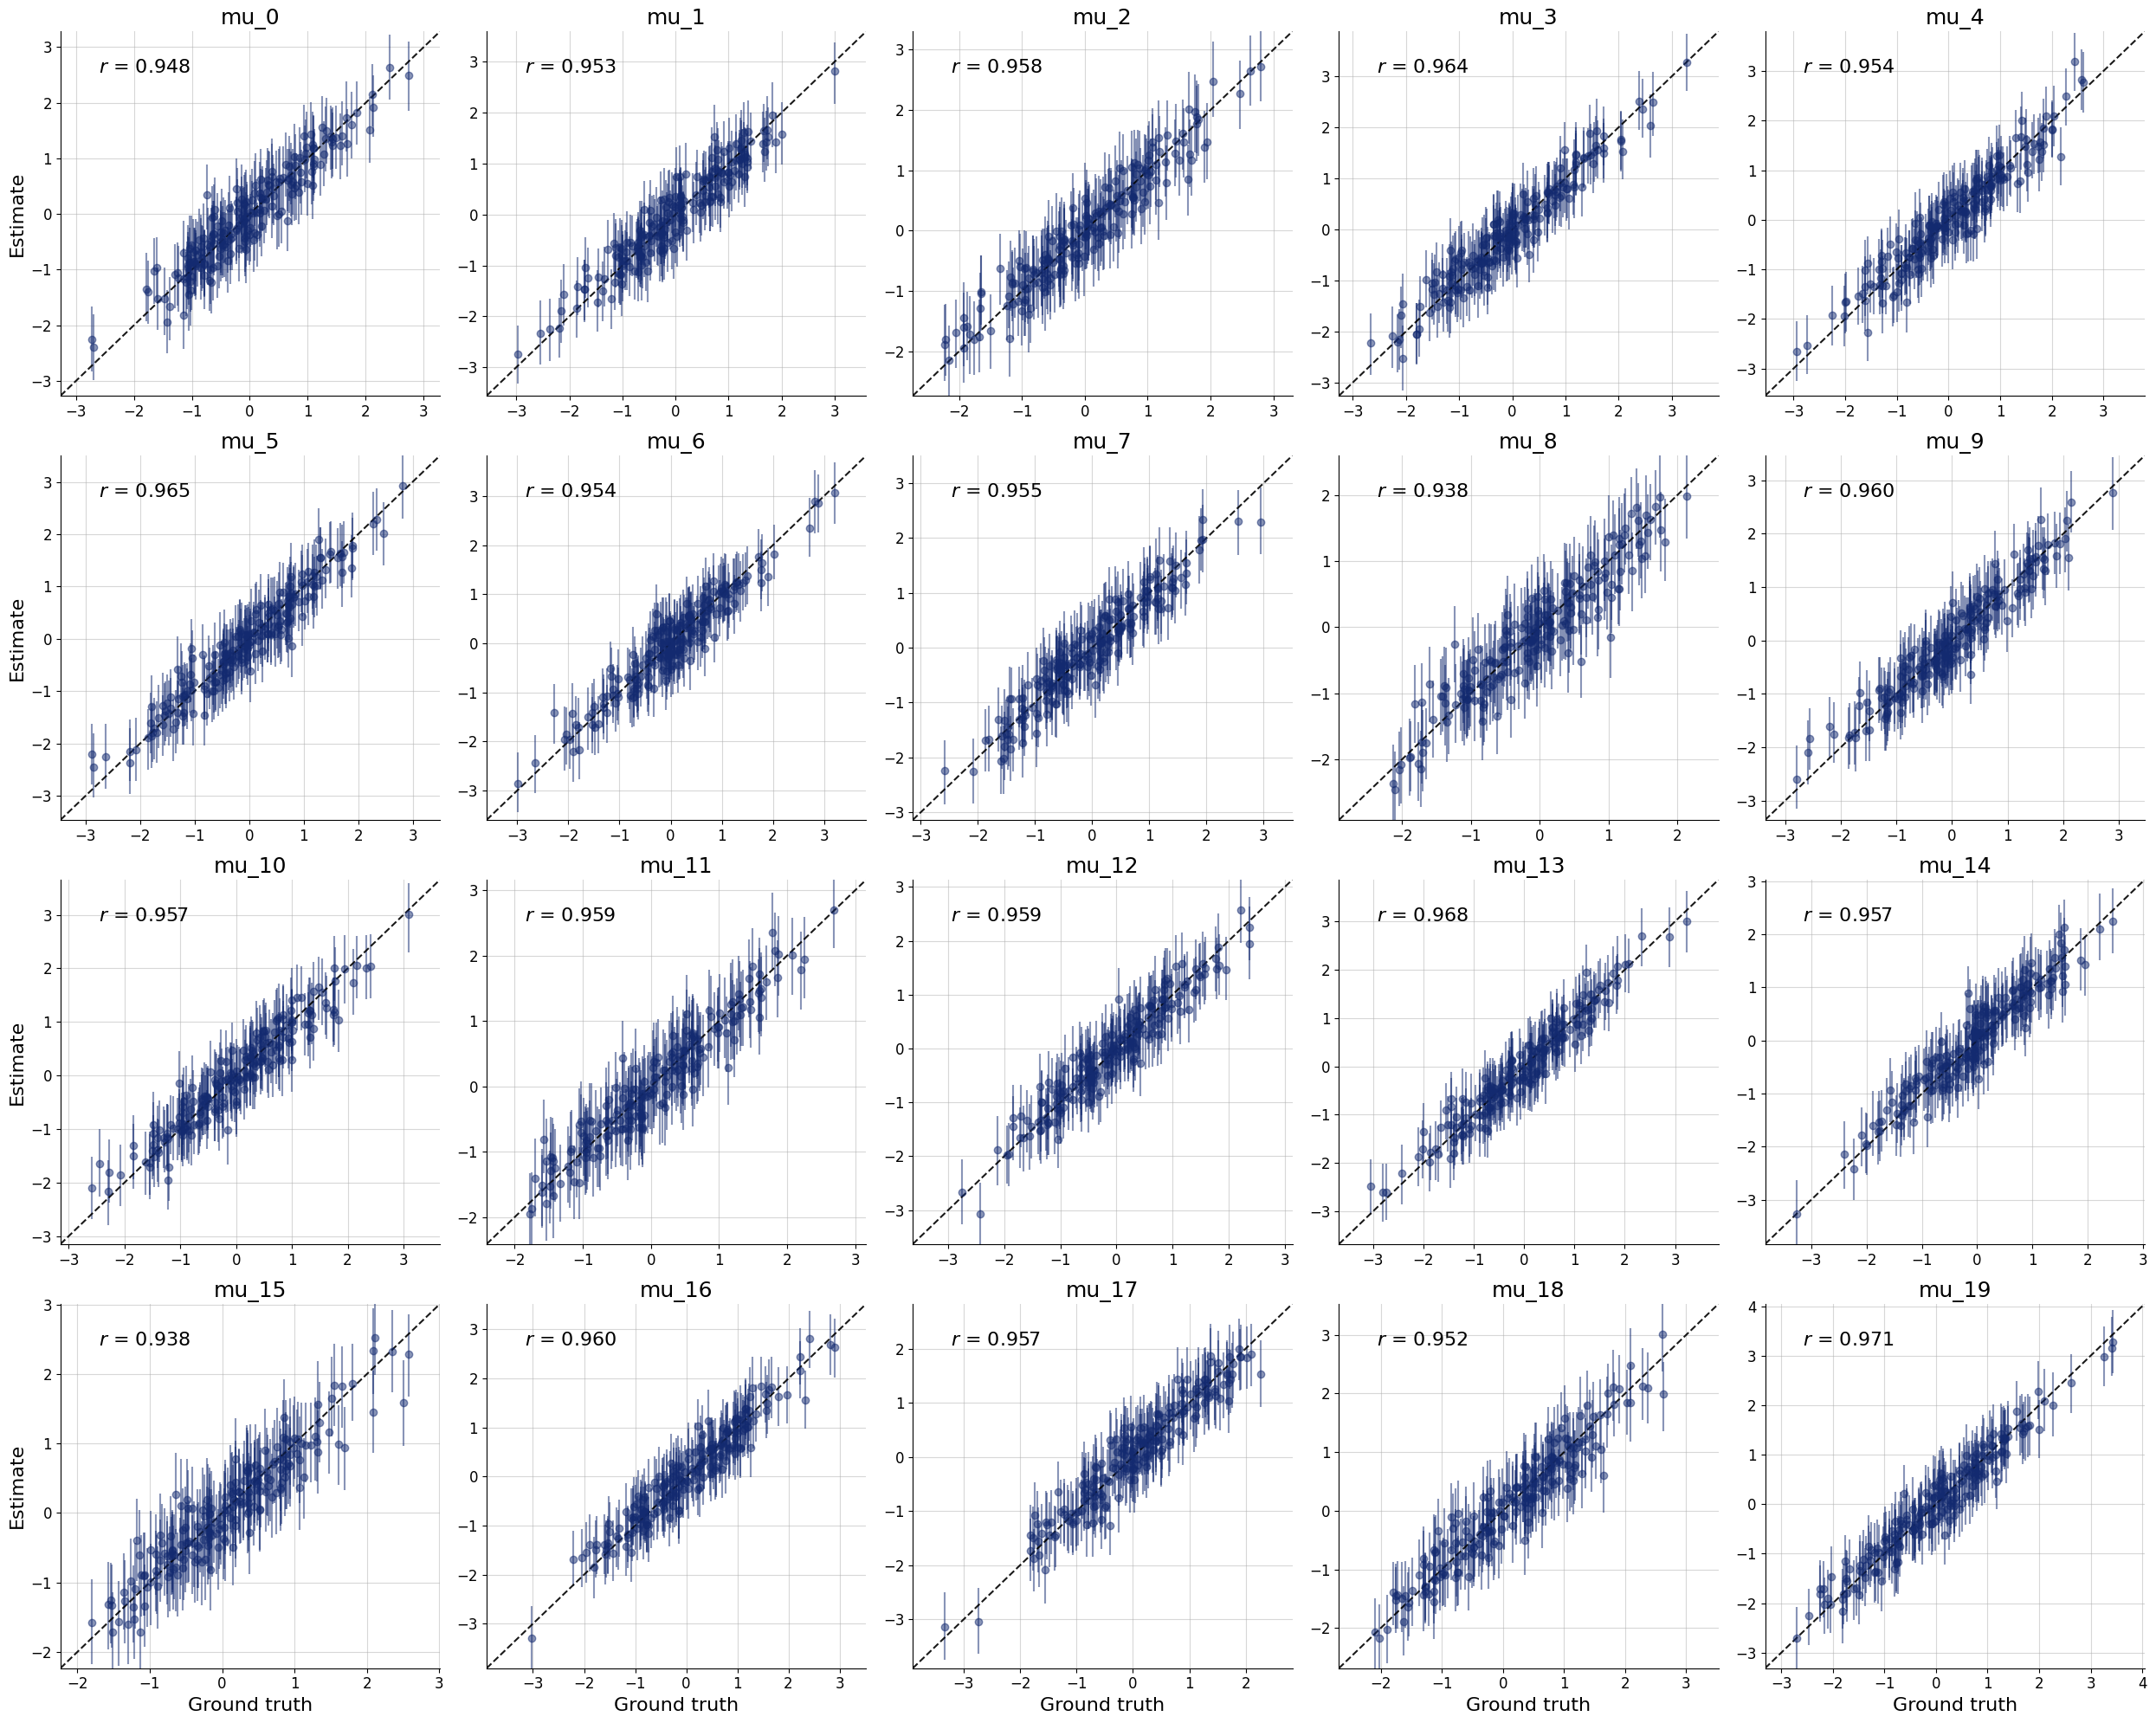

In [29]:
post_draws = approximator.sample(conditions=val_sims, num_samples=num_samples)
f3 = bf.diagnostics.plots.recovery(post_draws, val_sims)

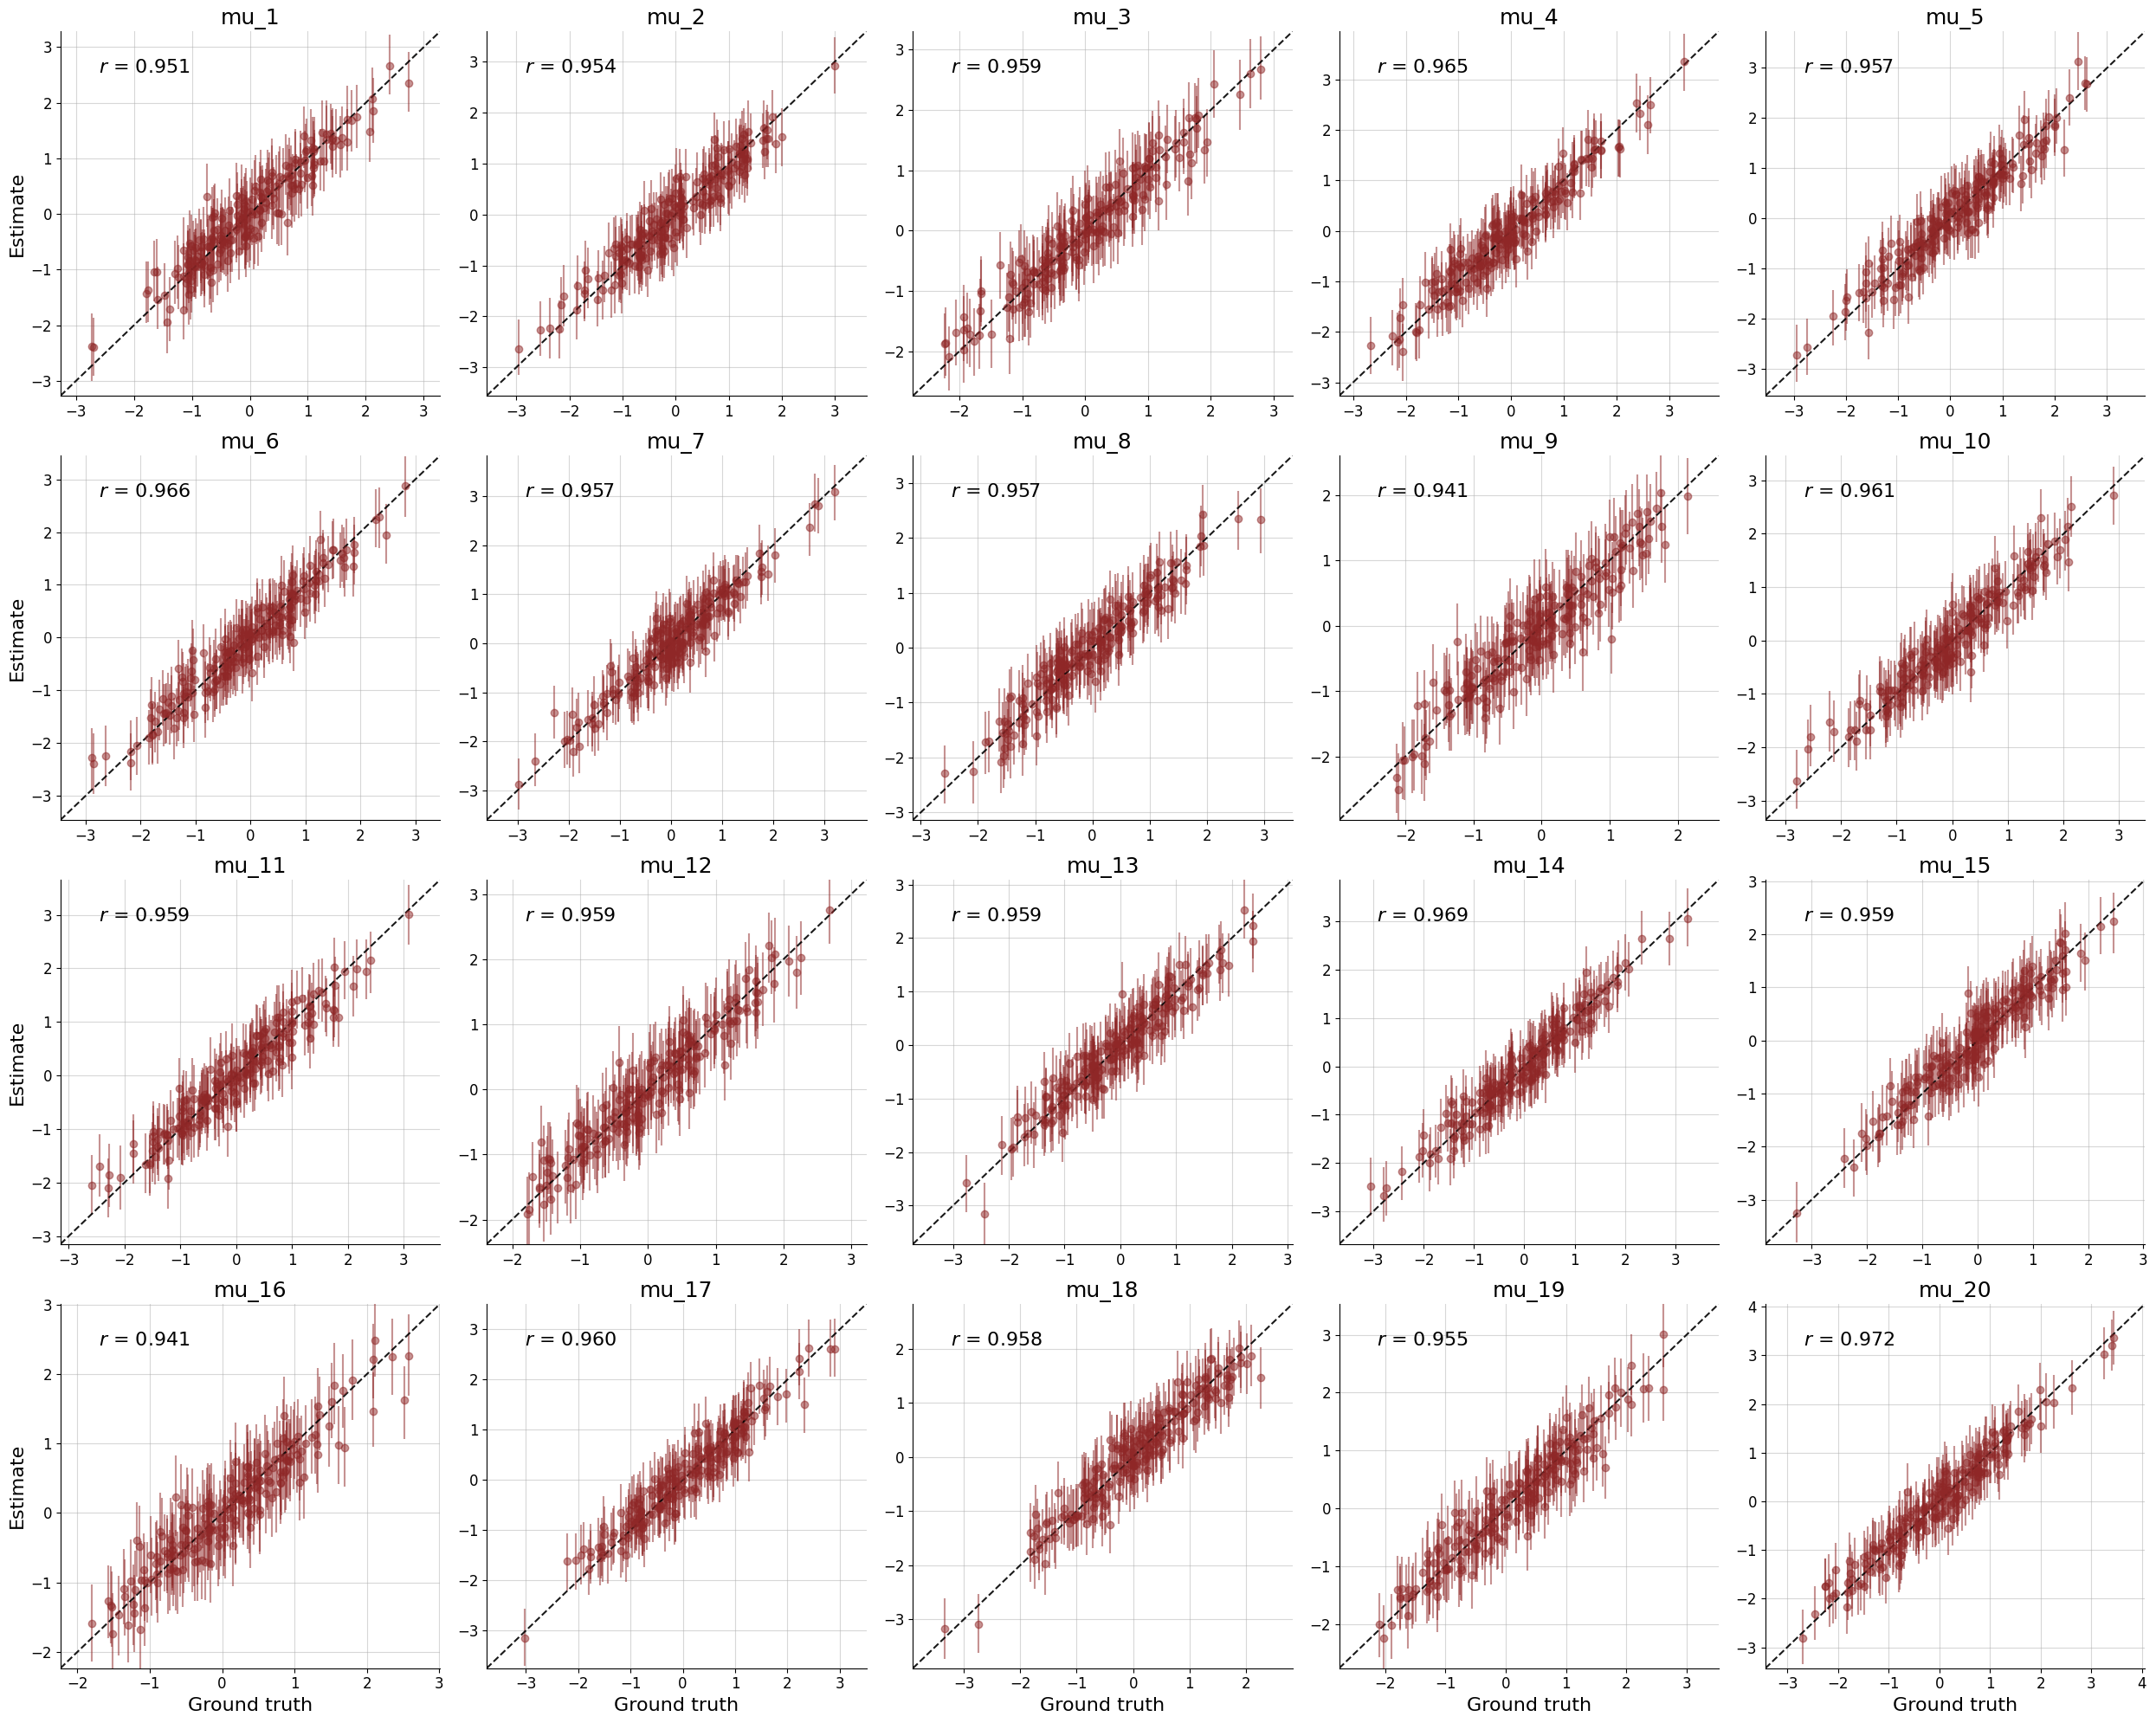

In [30]:
# Gold-standard recovery using samples from the analytical conjugate posterior
prior_precision = 1.0 / mu_prior_std**2
data_precision = num_obs / likelihood_std**2
gold_posterior_var = 1.0 / (prior_precision + data_precision)
gold_posterior_mean = gold_posterior_var * (
    prior_precision * mu_prior_mean
    + val_sims["x"].sum(axis=1) / likelihood_std**2
)

gold_rng = np.random.default_rng(2026)
gold_posterior_samples = gold_rng.normal(
    loc=gold_posterior_mean[:, None, :],
    scale=np.sqrt(gold_posterior_var),
    size=(gold_posterior_mean.shape[0], num_samples, num_dims),
)

f_gold_recovery = bf.diagnostics.plots.recovery(
    gold_posterior_samples,
    val_sims["mu"],
    variable_names=[f"mu_{i + 1}" for i in range(num_dims)],
    color="#8f2727",
)